In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('ushape.csv')

In [3]:
df.head()

,X,Y,class
0,0.031595,0.986988,0.0
1,2.115098,-0.046244,1.0
2,0.882490,-0.075756,0.0
3,-0.055144,-0.037332,1.0
4,0.829545,-0.539321,1.0


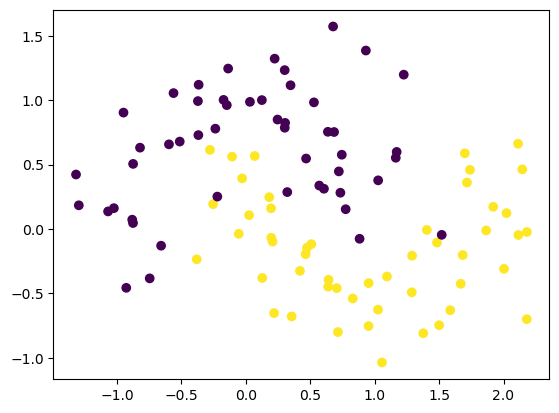

In [4]:
plt.scatter(df['X'],df['Y'],c=df['class'])

In [5]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [6]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [7]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2,kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(1,activation='sigmoid'))

model.summary()

C:\Users\avraj\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 10)                  │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.get_weights()

[array([[-1.0065899 , -0.08220079, -0.29513577, -0.30078083, -0.22202452,
          0.33014515,  2.0999148 , -0.8077544 ,  0.90039605, -0.5635295 ],
        [-1.9481963 , -0.3485533 ,  0.6592328 , -1.1616381 ,  0.5609421 ,
         -0.47707945, -0.94367075,  1.3277243 ,  1.4969991 ,  1.1128141 ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.16295348, -0.5858821 , -0.12553856,  0.91286844, -0.8074826 ,
         -0.41892442, -0.56065506,  0.3042299 ,  0.6175262 , -0.19261144],
        [-0.28369617, -0.20662344,  0.66336   , -0.5907368 ,  0.23463884,
         -0.0409201 , -0.5800591 ,  0.5114389 , -0.13540232, -0.0485253 ],
        [ 0.19901177,  0.58289933,  0.3765705 ,  0.07968877,  0.89662874,
          0.27772662,  0.19421132, -0.37011734,  0.24384278,  0.6664136 ],
        [ 0.02999473, -0.34724784, -0.20305552,  0.5292521 , -0.47876814,
         -0.7363729 ,  0.54183024, -0.53434265,  0.7394139 ,  0.13395534],
        [-0.58413

In [9]:
initial_weights = model.get_weights()

In [10]:
initial_weights[0] = np.random.randn(2,10)*np.sqrt(1/2)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)
initial_weights[4] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[5] = np.zeros(model.get_weights()[5].shape)
initial_weights[6] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[7] = np.zeros(model.get_weights()[7].shape)
initial_weights[8] = np.random.randn(10,1)*np.sqrt(1/10)
initial_weights[9] = np.zeros(model.get_weights()[9].shape)

In [11]:
model.set_weights(initial_weights)

In [12]:
model.get_weights()

[array([[-1.0496178 , -0.67513096,  0.58476645, -0.1248619 ,  0.37881646,
         -0.11304351,  0.31825083, -0.41068015, -0.6893424 , -0.6400144 ],
        [-0.25827128, -0.04812192,  1.8473656 ,  0.16005623,  1.620914  ,
         -1.1468612 ,  0.36079025, -0.28567326,  1.4897386 ,  1.220919  ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.49675098,  0.16808277, -0.32646692,  0.39832592,  0.17712109,
         -0.1004416 , -0.5923629 ,  0.01457547, -0.18866636,  0.24707298],
        [-0.02394315,  0.12643042, -0.91023916,  0.01237501, -0.38850263,
          0.5934013 ,  0.19201003,  0.335324  ,  0.33550087,  0.19761552],
        [-0.17157759, -0.15682228,  0.20547685,  0.7252108 , -0.6109663 ,
          0.3877576 ,  0.44626534, -0.0366216 ,  0.09781121, -0.12943521],
        [-0.22484933, -0.50250876, -0.04052515, -0.30916724,  0.1786885 ,
         -0.4039615 ,  0.3535737 ,  0.17060621,  0.10230809, -0.14361158],
        [-0.37961

In [13]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [14]:
history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - accuracy: 0.2625 - loss: 0.7003 - val_accuracy: 0.3500 - val_loss: 0.6997
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.3125 - loss: 0.6984 - val_accuracy: 0.2000 - val_loss: 0.6980
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.3250 - loss: 0.6967 - val_accuracy: 0.2000 - val_loss: 0.6964
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.3875 - loss: 0.6952 - val_accuracy: 0.2000 - val_loss: 0.6951
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.4375 - loss: 0.6939 - val_accuracy: 0.2500 - val_loss: 0.6939
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4750 - loss: 0.6928 - val_accuracy: 0.4000 - val_loss: 0.6929
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5000 - loss: 0.6919 - val_accuracy: 0.6000 - val_loss: 0.6920
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.6500 - loss: 0.6911 - val_accuracy: 0.7000 - val_loss:

In [15]:
model.get_weights()

[array([[-1.2057105 , -0.72188973,  0.3652276 , -0.1026646 ,  0.18025301,
          0.11626144,  0.5689874 , -0.2704395 , -0.5172219 , -0.56119794],
        [-0.4680069 , -0.05581138,  2.097106  ,  0.33611423,  1.867871  ,
         -1.4004574 ,  0.06617268, -0.4041941 ,  1.7001381 ,  1.5716444 ]],
       dtype=float32),
 array([-0.05122046,  0.14052604,  0.19469586,  0.04282409,  0.06967544,
         0.21254842,  0.2685138 , -0.19751471,  0.19746163,  0.2749927 ],
       dtype=float32),
 array([[ 0.7739514 ,  0.41235742,  0.00739538,  0.59688014,  0.17712109,
         -0.30587897, -0.37453815,  0.00796914, -0.15172634,  0.04947812],
        [ 0.24237141,  0.3304465 , -0.6327483 ,  0.16273852, -0.38850263,
          0.4485539 ,  0.31884536,  0.32866204,  0.45393628,  0.01267596],
        [-0.3418261 , -0.22509766,  0.3995539 ,  0.81078285, -0.62286943,
          0.5613407 ,  0.52536434, -0.0366216 ,  0.30369702, -0.02298233],
        [-0.04455644, -0.3894991 ,  0.20828404, -0.15456833, 

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 7s 719us/step


<Axes: >

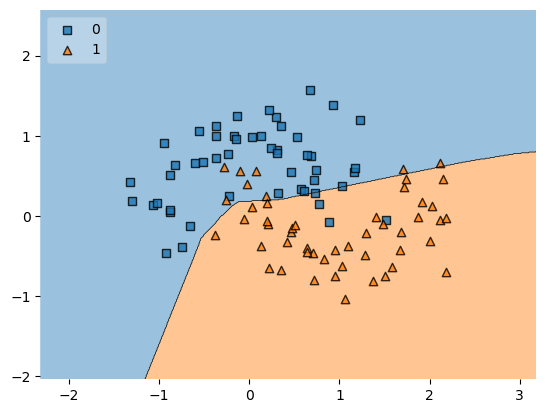

In [16]:
import numpy as np
from mlxtend.plotting import plot_decision_regions

class ModelWrapper:
    def __init__(self, model):
        self.model = model

    def predict(self, X):
        y_pred = self.model.predict(X)
        if y_pred.shape[1] == 1:      # single sigmoid output
            return (y_pred > 0.5).astype(int).reshape(-1)
        else:                          # softmax output
            return np.argmax(y_pred, axis=1)

plot_decision_regions(X, y.astype('int'), clf=ModelWrapper(model), legend=2)

In [17]:
(np.random.randn(10,10)*0.01).min()

np.float64(-0.027502729450441823)

In [18]:
(np.random.randn(10,10)*0.01).max()

np.float64(0.028600371482573383)